##**Project Overview**

This project uses a synthetic dataset from a music streaming application to explore which users are more likely to convert from a free trial to a paid Premium subscription.

**The main objective** is not only to identify variables associated with conversion, but also to build a business profile of higher-converting users.

To do this, the project combines **exploratory data analysis, statistical association testing, predictor correlation checks, multicollinearity analysis, and a composite trial engagement metric.**

<br>

#### **Structure**

0. Import: libraries, functions and sources
   
   0.0. Libraries import
   
   0.1. Functions and helpers import
   
   0.2. Sources import

1. Sources EDA
   
   1.0. Basic overview
   
   1.1. Data Exploration

2. Hypotheses and Research
   
   2.0. Hypotheses, Statistical Tools, and Significance Level
   
   2.1. Preparing data

   2.2. Statistical association testing

   2.3. Multicollinearity Check with VIF

   2.4. Final metrics

3. Final Results and Next Steps

###**0. Import: libraries, functions and sources**
####**0.0. Libraries import**

In [81]:
import google.colab as gc

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from scipy.stats import pointbiserialr
from scipy.stats.contingency import association
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler

####**0.1. Functions and helpers import**

In [47]:
# ==================================
# loading functions and color helper
# ==================================

!git clone -q https://github.com/MariiaKrt/music-app-proxy-metrics-analysis.git

import sys
from pathlib import Path

ROOT = Path('/content/music-app-proxy-metrics-analysis')
sys.path.insert(0, str(ROOT / 'src'))

from visual import viz_histogram, viz_hbars
from styles import colors


####**0.2. Sources import**

In [48]:
# ===============
# loading sources
# ===============

DATA_DIR = ROOT / 'data'

df = pd.read_csv(DATA_DIR / 'music_streaming_app_source.csv')

### **1. Sources EDA**

This section checks the dataset structure, data quality, and target distribution before the main analysis.

#### **1.0. Basic overview**

In [49]:
# =====================
# Data shape and subset
# =====================
print(df.shape)
df.sample(10)

(12000, 14)


,UserId,OnboardingCompletionScore,Country,Sex,Age,AccountAgeMonths,ListeningHours,ActiveDays,SkipRate,PlaylistCount,LikedTracks,RecommendationUsageRate,ImportedMusicLibrary,ConvertedToPremium
9746,1009747,66.5,Poland,Female,29,11,15.5,19,0.566,4,17,0.468,0,1
3591,1003592,60.4,France,Male,29,18,48.2,20,0.209,4,23,0.378,0,0
6219,1006220,79.5,Brazil,Female,45,24,26.2,18,0.320,2,15,0.382,1,0
8332,1008333,88.7,Spain,Female,34,15,13.8,15,0.301,3,9,0.308,1,1
8500,1008501,26.5,Poland,Male,26,27,0.5,9,0.539,1,7,0.156,0,0
1527,1001528,26.7,United Kingdom,Female,50,15,15.3,16,0.465,3,14,0.227,0,0
4547,1004548,67.9,Germany,Male,28,2,47.2,25,0.378,3,21,0.425,0,0
2815,1002816,87.2,France,Female,56,1,11.7,14,0.172,1,7,0.150,0,0
8972,1008973,62.4,Brazil,Female,30,19,33.8,19,0.159,2,22,0.517,1,1
10377,1010378,57.3,Brazil,Male,23,38,2.1,9,0.452,1,10,0.234,0,0


In [ ]:
# ===========
# Data types
# ===========
df.info()

In [ ]:
# ==============
# Nulls in data
# ==============
df.isna().sum()

In [ ]:
# ===========
# Duplicates
# ===========
df.duplicated().sum()

In [ ]:
# ===================================
# Column basic stats and descriptions
# ===================================
df.describe(include = 'all')

In [ ]:
# ===========================
# Creating a copy to work with
# ===========================
source = df.copy()

In [50]:
# ===================================
# Check if User ID is a unique column
# ===================================

print('Column has only unique values' if source['UserId'].nunique() == source['UserId'].count() else 'Column has duplicates')

Column has only unique values


**Intermediate result:** The dataset contains 12,000 user-level records. No missing values or duplicate rows were found, and `UserId` is unique for each user.

#### **1.1 Data Exploration**

The distributions of numeric variables and the proportions of categorical and binary features are reviewed to get an initial understanding of the dataset.

In [120]:
# ========================
# Share of Converted Users
# ========================
converted_share = source.groupby('ConvertedToPremium', as_index = False).agg(Users = ('UserId', 'count'))
converted_share['Users_share'] =  round(converted_share['Users'] / converted_share['Users'].sum() * 100, 2)

converted_share

,ConvertedToPremium,Users,Users_share
0,0,9199,76.66
1,1,2801,23.34


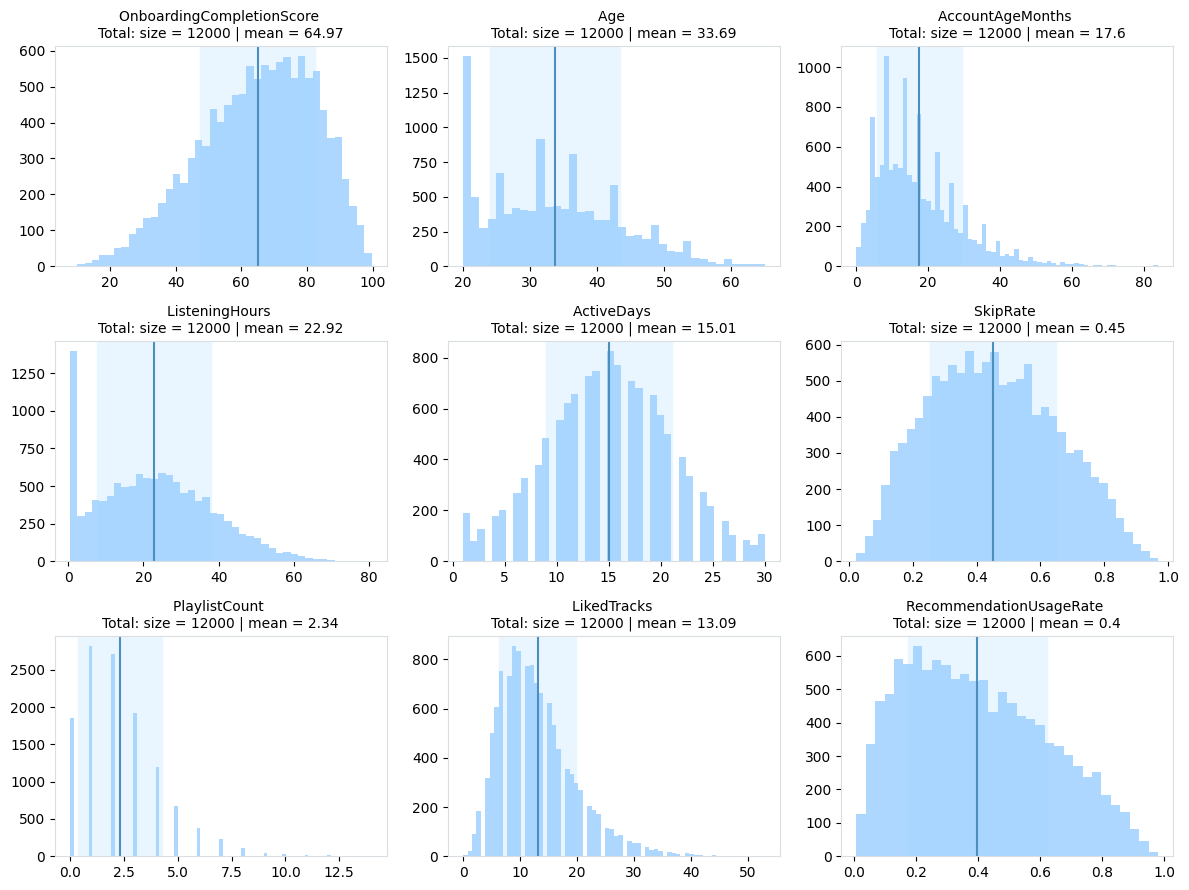

In [51]:
# =============================
# Numeric columns distributions
# =============================

data_for_histograms = [[source, 'OnboardingCompletionScore', 'mean', None, False],
                       [source, 'Age', 'mean', None, False],
                       [source, 'AccountAgeMonths', 'mean', None, False],
                       [source, 'ListeningHours', 'mean', None, False],
                       [source, 'ActiveDays', 'mean', None, False],
                       [source, 'SkipRate', 'mean', None, False],
                       [source, 'PlaylistCount', 'mean', None, False],
                       [source, 'LikedTracks', 'mean', None, False],
                       [source, 'RecommendationUsageRate', 'mean', None, False]
                       ]

columns = 3
rows = int(np.ceil(len(data_for_histograms) / columns))

fig, ax = plt.subplots(rows, columns, figsize = (rows * 4,  columns * 3))

for i, parameters in enumerate(data_for_histograms):
    row = i // columns
    col = i % columns

    viz_histogram(*parameters, ax = ax[row, col])

plt.tight_layout()
plt.show()


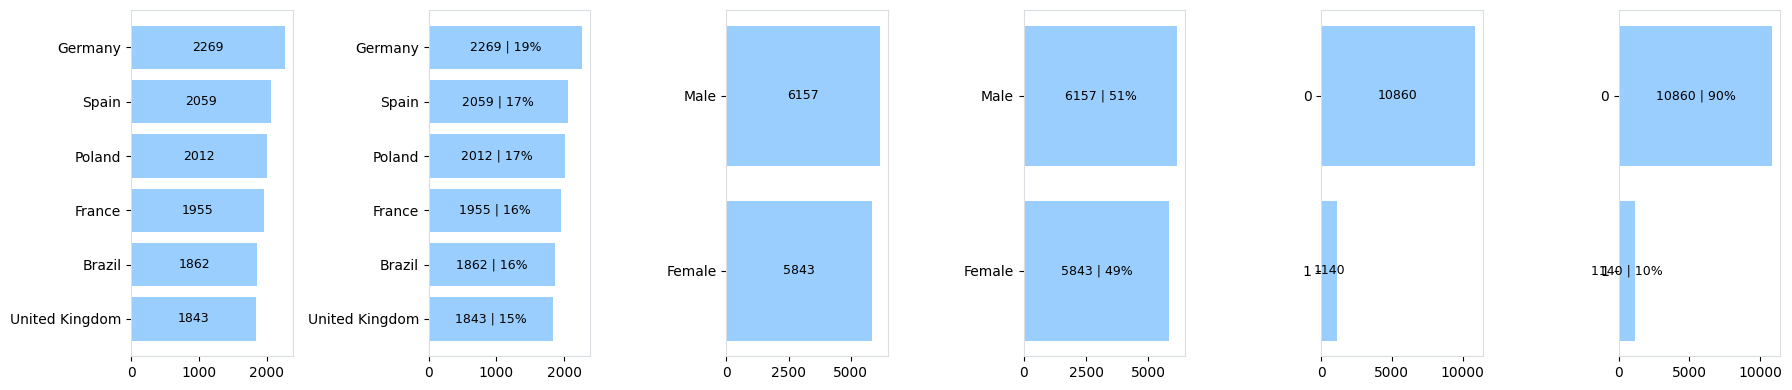

In [124]:
list_to_group = ['Country', 'Sex', 'ImportedMusicLibrary']
rel_list = [False, True]

fig, ax = plt.subplots(1, 6, figsize = (18, 4))
counter = 0

for l in list_to_group:
  for r in rel_list:
    viz_hbars (source, l, 'UserId', None, r, ax = ax[counter])
    counter += 1

plt.tight_layout()
plt.show()

**Intermediate result**

The dataset contains demographic variables (`Country`, `Sex`, `Age`), account-level features (`AccountAgeMonths`), onboarding behavior (`OnboardingCompletionScore`), and trial engagement metrics (`ListeningHours`, `ActiveDays`, `SkipRate`, `PlaylistCount`, `LikedTracks`, `RecommendationUsageRate`, `ImportedMusicLibrary`).  

About 23.3% of users converted to Premium. Sex is almost evenly split between male and female users, while country distribution is relatively balanced across the included markets.


**Distribution by the target feature**

Feature distributions are compared for users who converted and users who did not


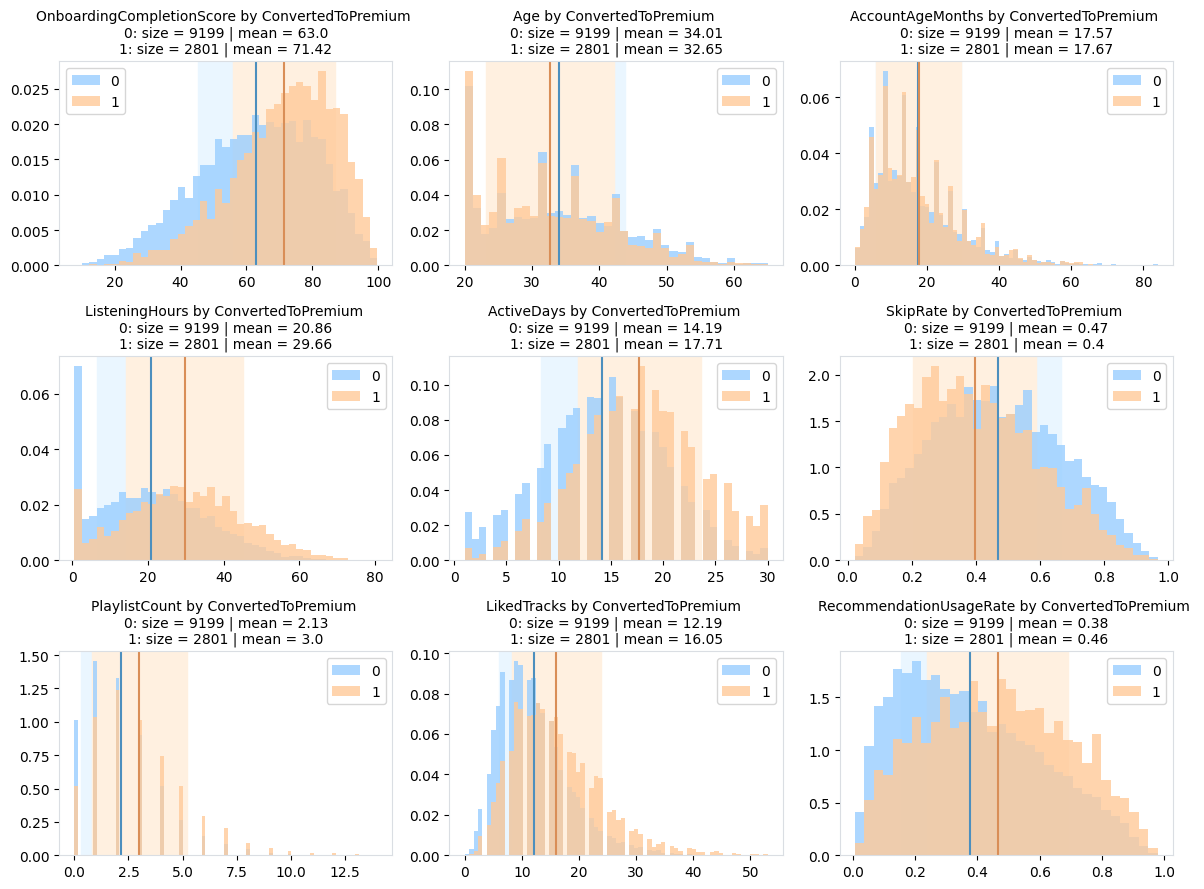

In [53]:
data_for_histograms = [[source, 'OnboardingCompletionScore', 'mean', 'ConvertedToPremium', True],
                       [source, 'Age', 'mean', 'ConvertedToPremium', True],
                       [source, 'AccountAgeMonths', 'mean', 'ConvertedToPremium', True],
                       [source, 'ListeningHours', 'mean', 'ConvertedToPremium', True],
                       [source, 'ActiveDays', 'mean', 'ConvertedToPremium', True],
                       [source, 'SkipRate', 'mean', 'ConvertedToPremium', True],
                       [source, 'PlaylistCount', 'mean', 'ConvertedToPremium', True],
                       [source, 'LikedTracks', 'mean', 'ConvertedToPremium', True],
                       [source, 'RecommendationUsageRate', 'mean', 'ConvertedToPremium', True]
                       ]

columns = 3
rows = int(np.ceil(len(data_for_histograms) / columns))

fig, ax = plt.subplots(rows, columns, figsize = (rows * 4,  columns * 3))

for i, parameters in enumerate(data_for_histograms):
    row = i // columns
    col = i % columns

    viz_histogram(*parameters, ax = ax[row, col])

plt.tight_layout()
plt.show()

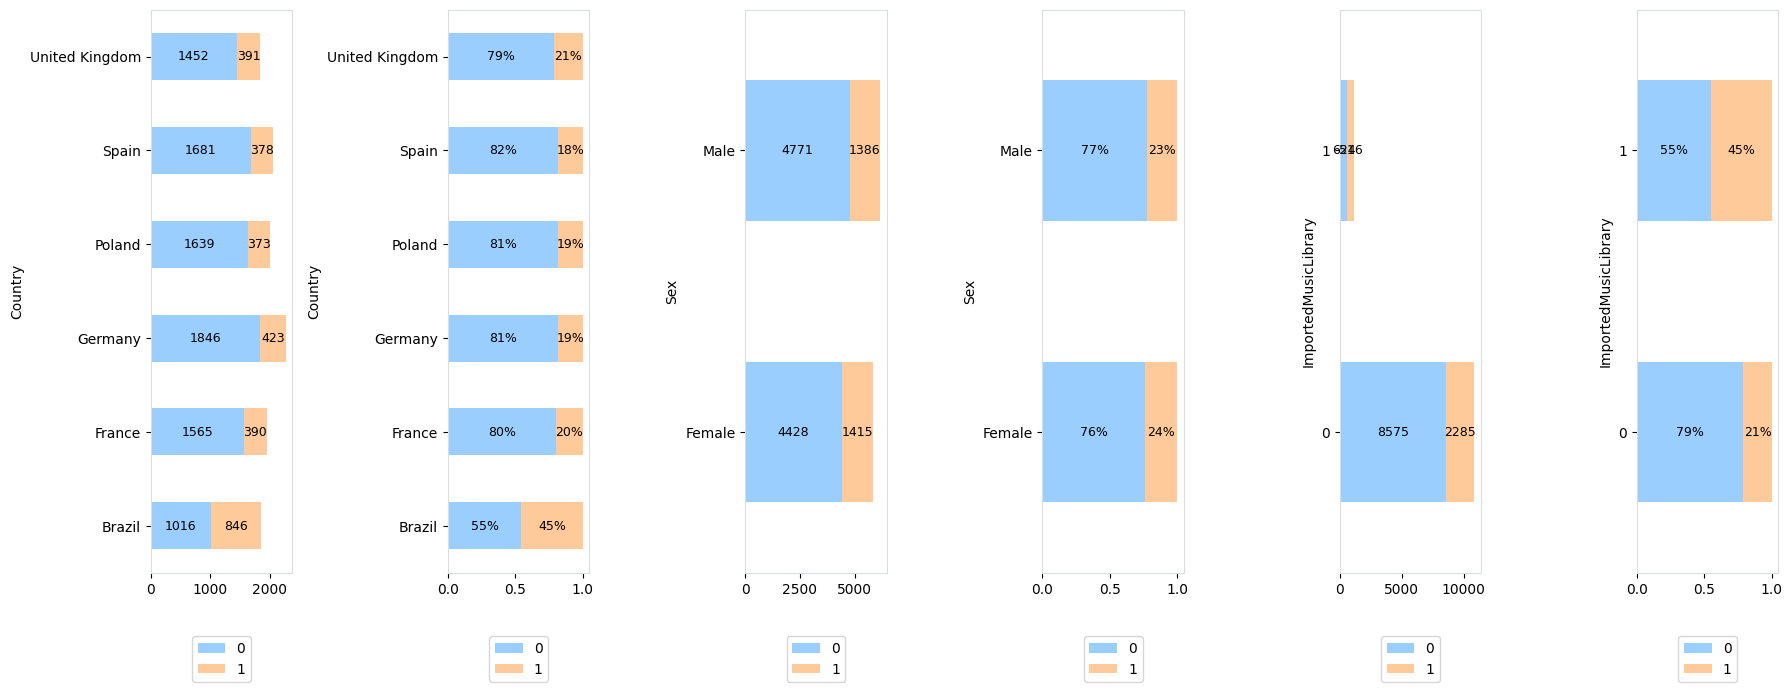

In [125]:
list_to_group = ['Country', 'Sex', 'ImportedMusicLibrary']
rel_list = [False, True]

fig, ax = plt.subplots(1, 6, figsize = (18, 7))
counter = 0

for l in list_to_group:
  for r in rel_list:
    viz_hbars (source, l, 'UserId', 'ConvertedToPremium', r , ax = ax[counter])
    counter += 1

plt.tight_layout()
plt.show()

**Intermediate result**

Converted and non-converted users differ mainly in product usage metrics.

**Converted users tend to have:**
- higher onboarding completion scores;
- more listening hours;
- more active days;
- more liked tracks;
- higher recommendation usage;
- slightly more playlists
- imported their libraries

**Skip rate shows the opposite pattern:**
- users who converted tend to have a lower skip rate.

**Weak or unclear differences:**
- age;
- account age;
- sex.

**Country difference:**
- the main country-level difference seems to come from Brazil. Other countries do not show a clear visual difference

### **2. Hypotheses and Research**

#### **2.0 Hypotheses, Statistical Tools, and Significance Level**

Based on the initial visual analysis, Premium conversion seems to be mainly related to user interest and engagement with the app.

The main hypothesis is that users are more likely to convert if they show stronger product engagement during the trial period.

Expected positive signals include:

- more listening hours
- more active days
- higher recommendation usage
- more liked tracks
- more playlists
- higher onboarding completion score
- importing a music library
- being located in Brazil

Demographic variables, such as age and sex, do not appear to be strong proxy signals for conversion.

<br>

**Statistical tools**

Target is Binary Type. Different statistical tests are used depending on the feature type.

| Feature type | Statistical test | Effect size |
|---|---|---|
| Quantitative | Point-biserial correlation | Correlation coefficient |
| Binary | Chi-square test | Phi coefficient |
| Categorical | Chi-square test | Cramér’s V |

<br>

**Features and Tools**

| Point-biserial correlation | Chi-square + Phi coefficient | Chi-square + Cramér’s V |
|---|---|---|
| OnboardingCompletionScore | Sex | Country |
| Age | ImportedMusicLibrary |  |
| AccountAgeMonths | country dummy variables |  |
| ListeningHours |  |  |
| ActiveDays |  |  |
| SkipRate |  |  |
| PlaylistCount |  |  |
| LikedTracks |  |  |
| RecommendationUsageRate |  |  |

<br>

**Significance level**

The significance level is set at 5% (alpha = 0.05)


<br>


####**2.1. Preparing data**

Pivoting Country column and converting Sex to binary 1/0 column

In [57]:
country_dummies = pd.get_dummies(source['Country'],
                                 prefix = 'country',
                                 drop_first = False).astype(int)
source_upd = pd.concat([source, country_dummies], axis = 1)
source_upd['Sex'] = np.where(source_upd['Sex'] == 'Female', 1, 0)
display(source_upd)

,UserId,OnboardingCompletionScore,Country,Sex,Age,AccountAgeMonths,ListeningHours,ActiveDays,SkipRate,PlaylistCount,LikedTracks,RecommendationUsageRate,ImportedMusicLibrary,ConvertedToPremium,country_Brazil,country_France,country_Germany,country_Poland,country_Spain,country_United Kingdom
0,1000001,35.2,United Kingdom,0,22,14,13.9,11,0.835,2,7,0.246,1,0,0,0,0,0,0,1
1,1000002,63.7,Brazil,1,20,16,0.5,9,0.523,1,5,0.312,1,1,1,0,0,0,0,0
2,1000003,63.5,Brazil,0,36,14,34.7,18,0.704,3,17,0.700,0,1,1,0,0,0,0,0
3,1000004,63.1,Brazil,1,38,13,10.7,12,0.789,2,6,0.160,0,1,1,0,0,0,0,0
4,1000005,67.7,Germany,0,22,32,30.9,11,0.486,1,13,0.198,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,1011996,54.9,Spain,0,39,6,0.5,3,0.567,1,8,0.119,0,0,0,0,0,0,1,0
11996,1011997,48.5,Spain,1,20,17,7.2,9,0.792,0,10,0.113,0,0,0,0,0,0,1,0
11997,1011998,90.1,Spain,1,32,29,41.7,28,0.091,6,22,0.206,0,1,0,0,0,0,1,0
11998,1011999,43.9,France,0,42,18,2.1,12,0.559,2,7,0.087,0,0,0,1,0,0,0,0


####**2.2. Statistical association testing**

Using chosen statistical tools, calculating correlations with the target

In [127]:
a = 0.05
stat_table = []

def build_stat_table(table, target_col, pb_columns, phi_columns, cramer_columns = None, alpha = 0.05):
    stat_table = []

    if cramer_columns is None:
        categorical_columns = []

    for column in pb_columns:
        st, p = pointbiserialr(table[target_col], table[column])
        stat_table.append([column, st, p, 'Point-Biserial', 'No' if p >= alpha else 'Yes'])

    for column in phi_columns:
        cross_tab = pd.crosstab(table[target_col], table[column])
        chi2, p, _, _ = chi2_contingency(cross_tab)
        n = cross_tab.to_numpy().sum()
        phi = np.sqrt(chi2 / n)

        stat_table.append([column, phi, p, 'Chi^2 + Phi', 'No' if p >= alpha else 'Yes'])

    for column in cramer_columns:
        cross_tab = pd.crosstab(table[target_col], table[column])
        st = association(cross_tab, method = 'cramer', correction = True)
        chi2, p, _, _ = chi2_contingency(cross_tab)

        stat_table.append([column, st, p, "Chi^2 + Cramer's V", 'No' if p >= alpha else 'Yes'])

    results = pd.DataFrame(
        stat_table,
        columns = ['Feature', 'Effect size', 'P-value', 'Test', 'Stat. Significance']
    )

    bins = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.1]
    labels = ['No/almost no', 'Weak', 'Weak/Moderate', 'Moderate', 'Strong', 'Very Strong']

    results['P-value'] = results['P-value'].round(4)
    results['Effect size'] = results['Effect size'].round(2)
    results['Effect_size_abs'] = results['Effect size'].abs()
    results['Result'] = pd.cut(results['Effect size'].abs(), bins = bins, labels = labels, include_lowest = True, right = False)
    results = results.sort_values(by = ['Effect_size_abs', 'P-value'], ascending = [False, True])
    results.reset_index(drop = True, inplace = True)
    results.drop(columns = 'Effect_size_abs', inplace = True)

    return results


pb_columns = ['OnboardingCompletionScore',
              'Age',
              'AccountAgeMonths',
              'ListeningHours',
              'ActiveDays',
              'SkipRate',
              'PlaylistCount',
              'LikedTracks',
              'RecommendationUsageRate']

phi_columns = ['Sex',
               'ImportedMusicLibrary',
               'country_Brazil',
               'country_France',
               'country_Germany',
               'country_Poland',
               'country_Spain',
               'country_United Kingdom']

cramer_columns = ['Country']

results = pd.DataFrame(build_stat_table(table = source_upd,
                                        target_col = 'ConvertedToPremium',
                                        pb_columns = pb_columns,
                                        phi_columns = phi_columns,
                                        cramer_columns = cramer_columns))
display(results)

,Feature,Effect size,P-value,Test,Stat. Significance,Result
0,ListeningHours,0.25,0.0000,Point-Biserial,Yes,Weak/Moderate
1,ActiveDays,0.24,0.0000,Point-Biserial,Yes,Weak/Moderate
2,LikedTracks,0.24,0.0000,Point-Biserial,Yes,Weak/Moderate
3,Country,0.23,0.0000,Chi^2 + Cramer's V,Yes,Weak/Moderate
4,country_Brazil,0.22,0.0000,Chi^2 + Phi,Yes,Weak/Moderate
5,OnboardingCompletionScore,0.20,0.0000,Point-Biserial,Yes,Weak/Moderate
6,PlaylistCount,0.19,0.0000,Point-Biserial,Yes,Weak
7,RecommendationUsageRate,0.17,0.0000,Point-Biserial,Yes,Weak
8,ImportedMusicLibrary,0.17,0.0000,Chi^2 + Phi,Yes,Weak
9,SkipRate,-0.15,0.0000,Point-Biserial,Yes,Weak


**! Note about multiple testing correction**

Multiple testing correction was considered and would be a correct next step since a lot of statistical tests are performed

However, most key findings have very small p-values, so applying a stricter correction such as Holm would not change the main conclusions. For this reason, the interpretation focuses mainly on effect size and business meaning rather than p-value alone.


**Intermediate result**

The variables that show the strongest associations with premium conversion are `ListeningHours`, `ActiveDays`, `LikedTracks`, `country_Brazil`, and `OnboardingCompletionScore`. However, before treating them as separate signals, it is important to check whether some of them duplicate each other.

This is especially relevant for variables describing the same user behavior such as listening hours and active days.

Spearman correlation is used to check relationships between predictor variables, since it captures monotonic associations and is less sensitive to non-normal distributions.

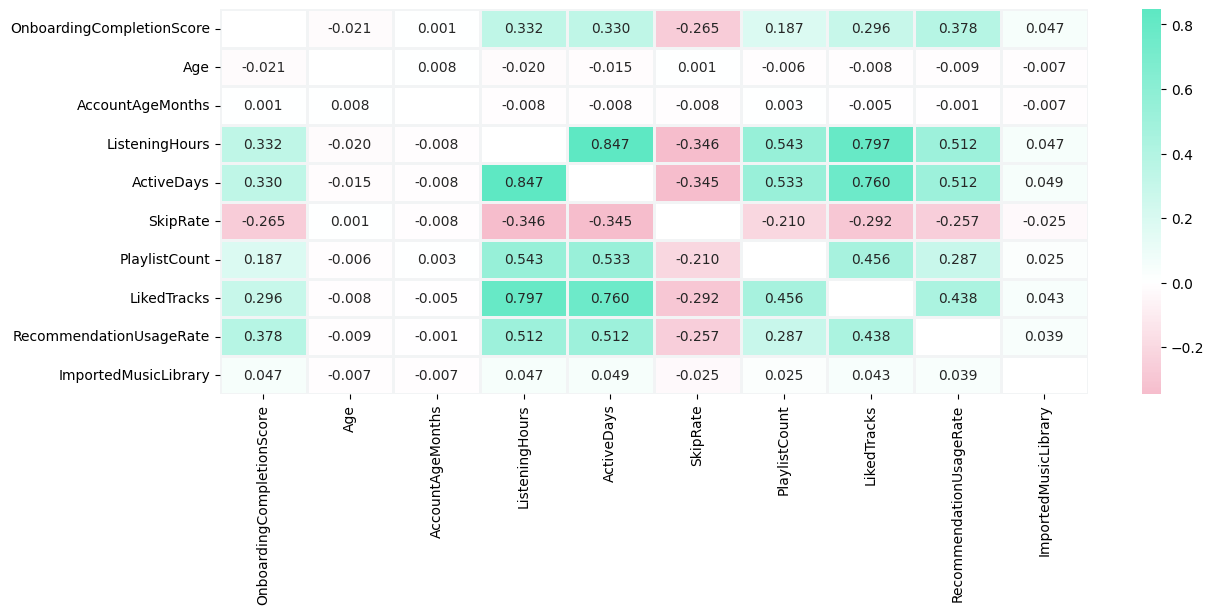

In [64]:
sp_columns = [
    'OnboardingCompletionScore',
    'Age',
    'AccountAgeMonths',
    'ListeningHours',
    'ActiveDays',
    'SkipRate',
    'PlaylistCount',
    'LikedTracks',
    'RecommendationUsageRate',
    'ImportedMusicLibrary'
]

my_cmap = LinearSegmentedColormap.from_list(
    'my_cmap',
    [colors['status']['negative'], '#FFFFFF' , colors['status']['positive']]
)

plt.figure(figsize = (14, 5))
corr = source[sp_columns].corr(method = 'spearman')
mask = np.eye(corr.shape[0], dtype = bool)
sns.heatmap(corr, annot = True, cmap = my_cmap, center = 0, fmt='.3f', mask = mask, linewidths = 1, linecolor = colors['neutral']['light'])
plt.show()


**Intermediate results**

The Spearman correlation matrix confirms overlap among the main engagement variables.

`ListeningHours` and `ActiveDays` show the strongest relationship, suggesting that users who listen more also tend to be active on more days. `LikedTracks` is also strongly related to both of these variables.

This means that these features should be interpreted as related engagement signals rather than fully separate drivers of conversion.

####**2.3. Multicollinearity Check with VIF**

VIF is used to check if predictors duplicate each other in the full feature set. The constant term is not interpreted as a feature.

In [122]:
x = source_upd.drop(columns = ['UserId', 'ConvertedToPremium', 'Country'])
x = x.drop(columns = ['country_United Kingdom'])
x = add_constant(x)

vif_table = pd.DataFrame({
    'Feature': x.columns,
    'VIF': [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
})

vif_results = vif_table.sort_values('VIF', ascending = False)

vif_bins = [0, 2, 5, 10, 1000]
vif_labels = ['Low', 'Moderate', 'Noticeable', 'Strong']

vif_results['Result'] = pd.cut(vif_results['VIF'], bins = vif_bins, labels = vif_labels, include_lowest = True, right = False)
display(vif_results)

,Feature,VIF,Result
0,const,55.160291,Strong
5,ListeningHours,4.956593,Moderate
6,ActiveDays,3.971794,Moderate
9,LikedTracks,3.091940,Moderate
14,country_Germany,1.809933,Low
16,country_Spain,1.754831,Low
15,country_Poland,1.742140,Low
13,country_France,1.725887,Low
12,country_Brazil,1.700425,Low
8,PlaylistCount,1.546409,Low


**Intermediate results**

The VIF check does not indicate severe multicollinearity among the predictor variables.

All feature VIF values are below 5. The highest values are observed for `ListeningHours`, `ActiveDays`, and `LikedTracks`, which is consistent with the strong overlap between engagement-related metrics found in the Spearman correlation matrix.


In [129]:
engagement_cols = ['ListeningHours', 'ActiveDays']

scaler = StandardScaler()

engagement_scaled = scaler.fit_transform(source_upd[engagement_cols])

source_upd['TrialEngagementIndex'] = engagement_scaled.mean(axis=1)

####**2.4. Final metrics**

In [130]:
pb_columns = ['OnboardingCompletionScore',
              'Age',
              'AccountAgeMonths',
              'TrialEngagementIndex',
              'SkipRate',
              'PlaylistCount',
              'LikedTracks',
              'RecommendationUsageRate']

phi_columns = ['Sex',
               'ImportedMusicLibrary',
               'country_Brazil',
               'country_France',
               'country_Germany',
               'country_Poland',
               'country_Spain',
               'country_United Kingdom']

cramer_columns = ['Country']

results = pd.DataFrame(build_stat_table(table = source_upd,
                                        target_col = 'ConvertedToPremium',
                                        pb_columns = pb_columns,
                                        phi_columns = phi_columns,
                                        cramer_columns = cramer_columns))
results

,Feature,Effect size,P-value,Test,Stat. Significance,Result
0,TrialEngagementIndex,0.25,0.0000,Point-Biserial,Yes,Weak/Moderate
1,LikedTracks,0.24,0.0000,Point-Biserial,Yes,Weak/Moderate
2,Country,0.23,0.0000,Chi^2 + Cramer's V,Yes,Weak/Moderate
3,country_Brazil,0.22,0.0000,Chi^2 + Phi,Yes,Weak/Moderate
4,OnboardingCompletionScore,0.20,0.0000,Point-Biserial,Yes,Weak/Moderate
5,PlaylistCount,0.19,0.0000,Point-Biserial,Yes,Weak
6,RecommendationUsageRate,0.17,0.0000,Point-Biserial,Yes,Weak
7,ImportedMusicLibrary,0.17,0.0000,Chi^2 + Phi,Yes,Weak
8,SkipRate,-0.15,0.0000,Point-Biserial,Yes,Weak
9,Age,-0.06,0.0000,Point-Biserial,Yes,No/almost no


**Intermediate result**

The `TrialEngagementIndex` does not create a stronger association with conversion than the original engagement variables. Its effect size remains close to `ListeningHours` and `ActiveDays` individually.

However, the index keeps almost the same signal while combining two strongly related features into one metric.

###**3. Final Results and Next Steps**

The analysis shows that Premium conversion is mainly associated with trial engagement.

The strongest signals are `ListeningHours`, `ActiveDays`, `LikedTracks`, `OnboardingCompletionScore`, and `country_Brazil`. Users who listen more, use the app more regularly, complete onboarding, and like more tracks are more likely to convert.

Feature usage also matters, although the associations are weaker. Users who create playlists, use recommendations, or import their music library show higher conversion tendency.

Demographic variables are much weaker. `Sex` and `Age` show little practical association with conversion, while `AccountAgeMonths` does not show a meaningful relationship.

Country also appears to matter. The main country-level difference is driven by Brazil, where users show a higher conversion rate than in other markets.

The `TrialEngagementIndex` provides a compact engagement summary. It does not improve the association strength compared with the original engagement variables, but it keeps almost the same signal in a simpler form.

<br>

**Next Steps**

This analysis identifies useful proxy metrics for Premium conversion, but most of them are measured across the trial period. For a real product use case, this may be too late for early intervention.

The next step is to repeat the analysis using only early-trial behavior, such as activity from the first few days or the first week. This would show whether the same signals can predict conversion earlier.

The findings also suggest potential activation areas: onboarding completion, regular listening, liking tracks, recommendation usage, and music library import. These behaviors are associated with higher conversion and can be tested as product levers.